# Fresnel Dataset Analysis
This notebook analyses the input-output dataset generated by `generate_fresnel_dataset.py` for training a **Fourier Neural Operator (FNO)** to model Fresnel diffraction propagation of a Gaussian beam.

Each sample in the dataset contains:
- **Input** `(3, N, N)` — `[z (broadcast), Re(E_in), Im(E_in)]`
- **Output** `(2, N, N)` — `[Re(E_out), Im(E_out)]`
- **Propagation distance** `z` drawn uniformly from `[z_min, z_max]`

## 1. Import Libraries & Configure Paths

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

# ── Configure dataset path here ──────────────────────────────────────────────
DATASET_DIR = Path("fresnel_dataset")   # relative to this notebook
# ─────────────────────────────────────────────────────────────────────────────

# Physical constants (must match generation script)
um = 1e-6
mm = 1e-3

LAMBDA = 0.78 * um
W0     = 0.10 * mm

inputs_path    = DATASET_DIR / "inputs.npy"
outputs_path   = DATASET_DIR / "outputs.npy"
distances_path = DATASET_DIR / "prop_distances.npy"

print(f"Dataset directory : {DATASET_DIR.resolve()}")
print(f"inputs.npy exists : {inputs_path.exists()}")
print(f"outputs.npy exists: {outputs_path.exists()}")

Dataset directory : C:\Users\tjaouni\Desktop\Eigen\fresnel_dataset
inputs.npy exists : True
outputs.npy exists: True


## 2. Load Dataset & Inspect Structure

In [2]:
inputs         = np.load(inputs_path)         # (N, 3, res, res)
outputs        = np.load(outputs_path)        # (N, 2, res, res)
prop_distances = np.load(distances_path)      # (N,)

n_samples, _, res, _ = inputs.shape

print("─── Array shapes ───────────────────────────────")
print(f"  inputs          : {inputs.shape}   dtype={inputs.dtype}")
print(f"  outputs         : {outputs.shape}  dtype={outputs.dtype}")
print(f"  prop_distances  : {prop_distances.shape} dtype={prop_distances.dtype}")

print("\n─── Propagation distance statistics (m) ────────")
print(f"  min  : {prop_distances.min():.4f}")
print(f"  max  : {prop_distances.max():.4f}")
print(f"  mean : {prop_distances.mean():.4f}")
print(f"  std  : {prop_distances.std():.4f}")

# Reconstruct complex fields as (N, res, res) complex arrays
E_in  = inputs[:, 1, :, :].astype(np.float64)  + 1j * inputs[:, 2, :, :].astype(np.float64)
E_out = outputs[:, 0, :, :].astype(np.float64) + 1j * outputs[:, 1, :, :].astype(np.float64)
z_arr = inputs[:, 0, 0, 0].astype(np.float64)   # propagation distance per sample

print(f"\n  E_in  shape : {E_in.shape}  (complex128)")
print(f"  E_out shape : {E_out.shape} (complex128)")

─── Array shapes ───────────────────────────────
  inputs          : (1000, 3, 128, 128)   dtype=float32
  outputs         : (1000, 2, 128, 128)  dtype=float32
  prop_distances  : (1000,) dtype=float64

─── Propagation distance statistics (m) ────────
  min  : -0.0402
  max  : 0.0402
  mean : -0.0002
  std  : 0.0235

  E_in  shape : (1000, 128, 128)  (complex128)
  E_out shape : (1000, 128, 128) (complex128)


## 3. Visualize Input Fields (Intensity & Phase)
A few randomly selected source fields from the dataset. Because the source field is the same Gaussian for every sample, all inputs are identical — this confirms data consistency.

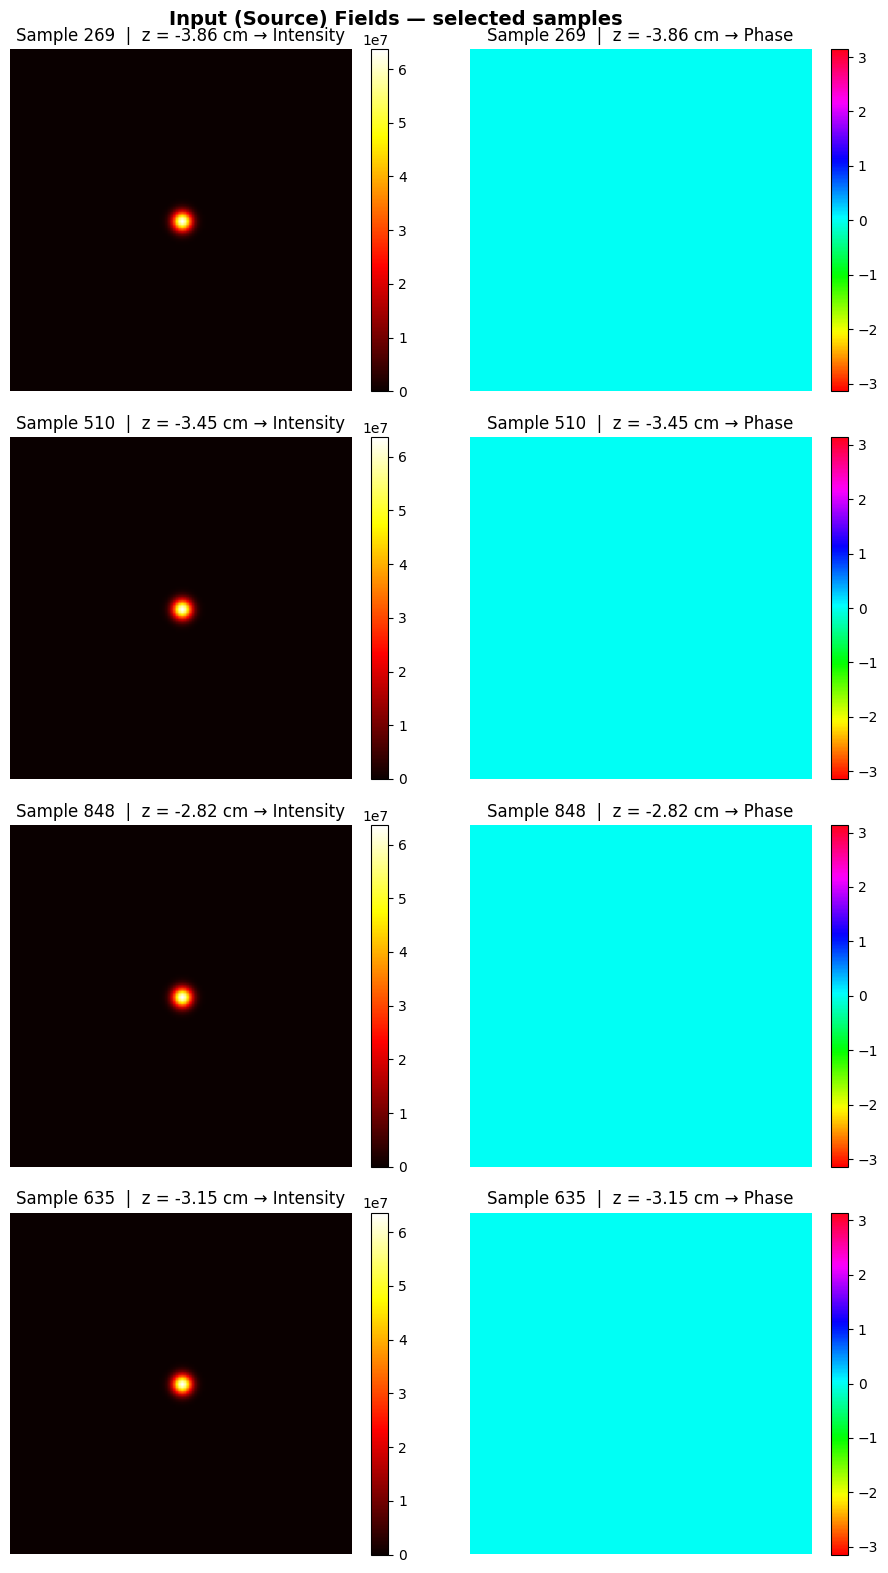

In [3]:
rng = np.random.default_rng(0)
sample_idx = rng.choice(n_samples, size=4, replace=False)

def plot_field(ax_int, ax_phase, E, title_prefix=""):
    """Plot intensity and phase of a complex field onto provided axes."""
    I = np.abs(E)**2
    im0 = ax_int.imshow(I, cmap="hot")
    ax_int.set_title(f"{title_prefix} Intensity")
    ax_int.axis("off")
    plt.colorbar(im0, ax=ax_int, fraction=0.046, pad=0.04)

    im1 = ax_phase.imshow(np.angle(E), cmap="hsv", vmin=-np.pi, vmax=np.pi)
    ax_phase.set_title(f"{title_prefix} Phase")
    ax_phase.axis("off")
    plt.colorbar(im1, ax=ax_phase, fraction=0.046, pad=0.04)

fig, axes = plt.subplots(4, 2, figsize=(10, 16))
fig.suptitle("Input (Source) Fields — selected samples", fontsize=14, fontweight="bold")

for row, idx in enumerate(sample_idx):
    plot_field(axes[row, 0], axes[row, 1], E_in[idx],
               title_prefix=f"Sample {idx}  |  z = {z_arr[idx]*100:.2f} cm →")

plt.tight_layout()
plt.show()

## 4. Visualize Output (Propagated) Fields
The same samples as above, but now showing the Fresnel-propagated outputs. You should see the beam spreading as z increases.

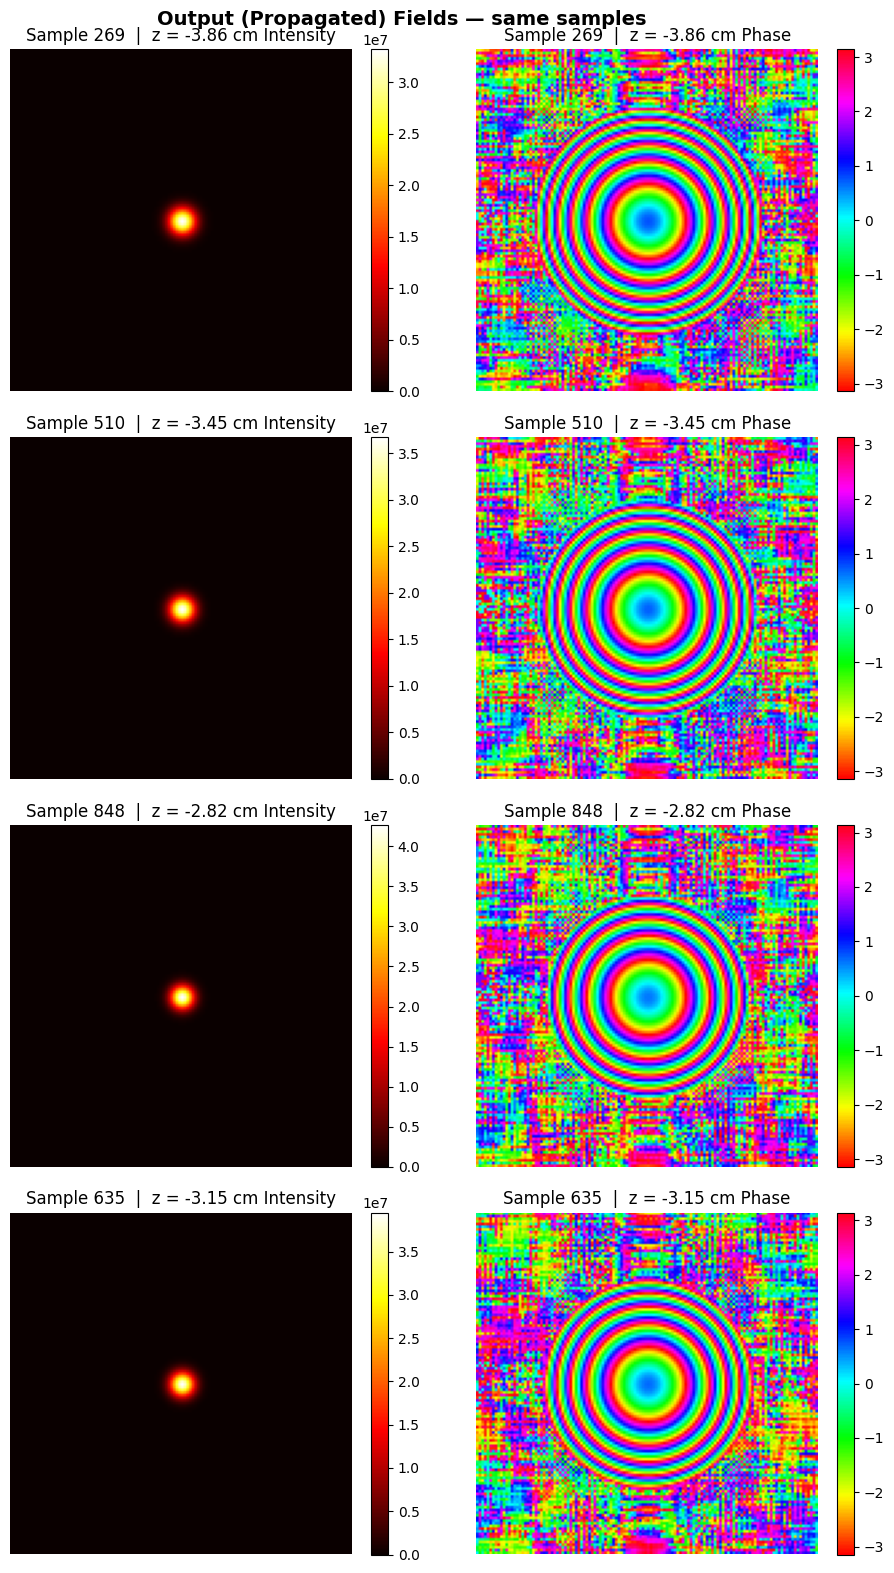

In [4]:
fig, axes = plt.subplots(4, 2, figsize=(10, 16))
fig.suptitle("Output (Propagated) Fields — same samples", fontsize=14, fontweight="bold")

for row, idx in enumerate(sample_idx):
    plot_field(axes[row, 0], axes[row, 1], E_out[idx],
               title_prefix=f"Sample {idx}  |  z = {z_arr[idx]*100:.2f} cm")

plt.tight_layout()
plt.show()

## 5. Propagation Distance Distribution
Histogram of the sampled propagation distances. We expect a uniform distribution between `z_min` and `z_max`.

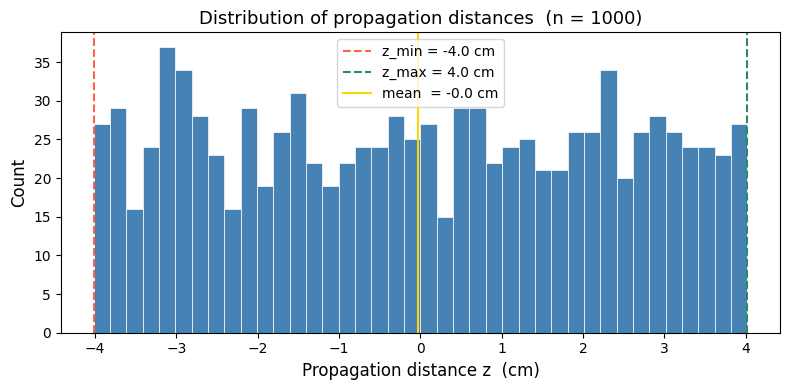

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(prop_distances * 100, bins=40, color="steelblue", edgecolor="white", linewidth=0.5)
ax.set_xlabel("Propagation distance z  (cm)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title(f"Distribution of propagation distances  (n = {n_samples})", fontsize=13)
ax.axvline(prop_distances.min() * 100, color="tomato",  linestyle="--", label=f"z_min = {prop_distances.min()*100:.1f} cm")
ax.axvline(prop_distances.max() * 100, color="seagreen", linestyle="--", label=f"z_max = {prop_distances.max()*100:.1f} cm")
ax.axvline(prop_distances.mean() * 100, color="gold", linestyle="-",  label=f"mean  = {prop_distances.mean()*100:.1f} cm")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Energy Conservation Check
Fresnel propagation is unitary — total intensity $I = \sum |E|^2 \cdot h^2$ should be preserved.  
We compute it for every sample and scatter input vs output total intensity; points should lie on the line $y = x$.

Mean relative energy error : 2.40e-08
Max  relative energy error : 5.99e-08


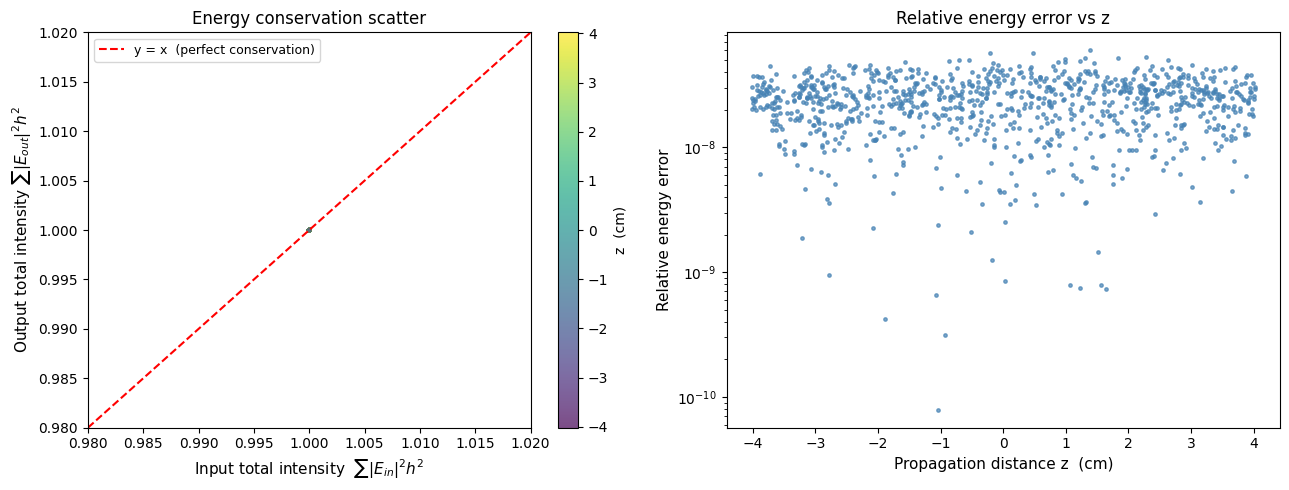

In [6]:
maxx = 20 * um * res
h    = maxx / res                       # grid step (m)

# Total intensity: sum over spatial axes, weighted by h^2
I_in  = np.sum(np.abs(E_in)**2,  axis=(-2, -1)) * h**2
I_out = np.sum(np.abs(E_out)**2, axis=(-2, -1)) * h**2

rel_error = np.abs(I_in - I_out) / I_in

print(f"Mean relative energy error : {rel_error.mean():.2e}")
print(f"Max  relative energy error : {rel_error.max():.2e}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter plot
sc = axes[0].scatter(I_in, I_out, c=z_arr * 100, cmap="viridis", s=6, alpha=0.7)
lims = [min(I_in.min(), I_out.min()) * 0.98, max(I_in.max(), I_out.max()) * 1.02]
axes[0].plot(lims, lims, "r--", linewidth=1.5, label="y = x  (perfect conservation)")
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_xlabel("Input total intensity  $\\sum|E_{in}|^2 h^2$", fontsize=11)
axes[0].set_ylabel("Output total intensity $\\sum|E_{out}|^2 h^2$", fontsize=11)
axes[0].set_title("Energy conservation scatter", fontsize=12)
axes[0].legend(fontsize=9)
plt.colorbar(sc, ax=axes[0], label="z  (cm)")

# Relative error vs z
axes[1].scatter(z_arr * 100, rel_error, s=6, alpha=0.7, color="steelblue")
axes[1].set_xlabel("Propagation distance z  (cm)", fontsize=11)
axes[1].set_ylabel("Relative energy error", fontsize=11)
axes[1].set_title("Relative energy error vs z", fontsize=12)
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

## 7. Input vs Output Field Pairs Side by Side
A gallery showing several input/output intensity pairs annotated with their propagation distance — a direct preview of what the FNO will be asked to learn.

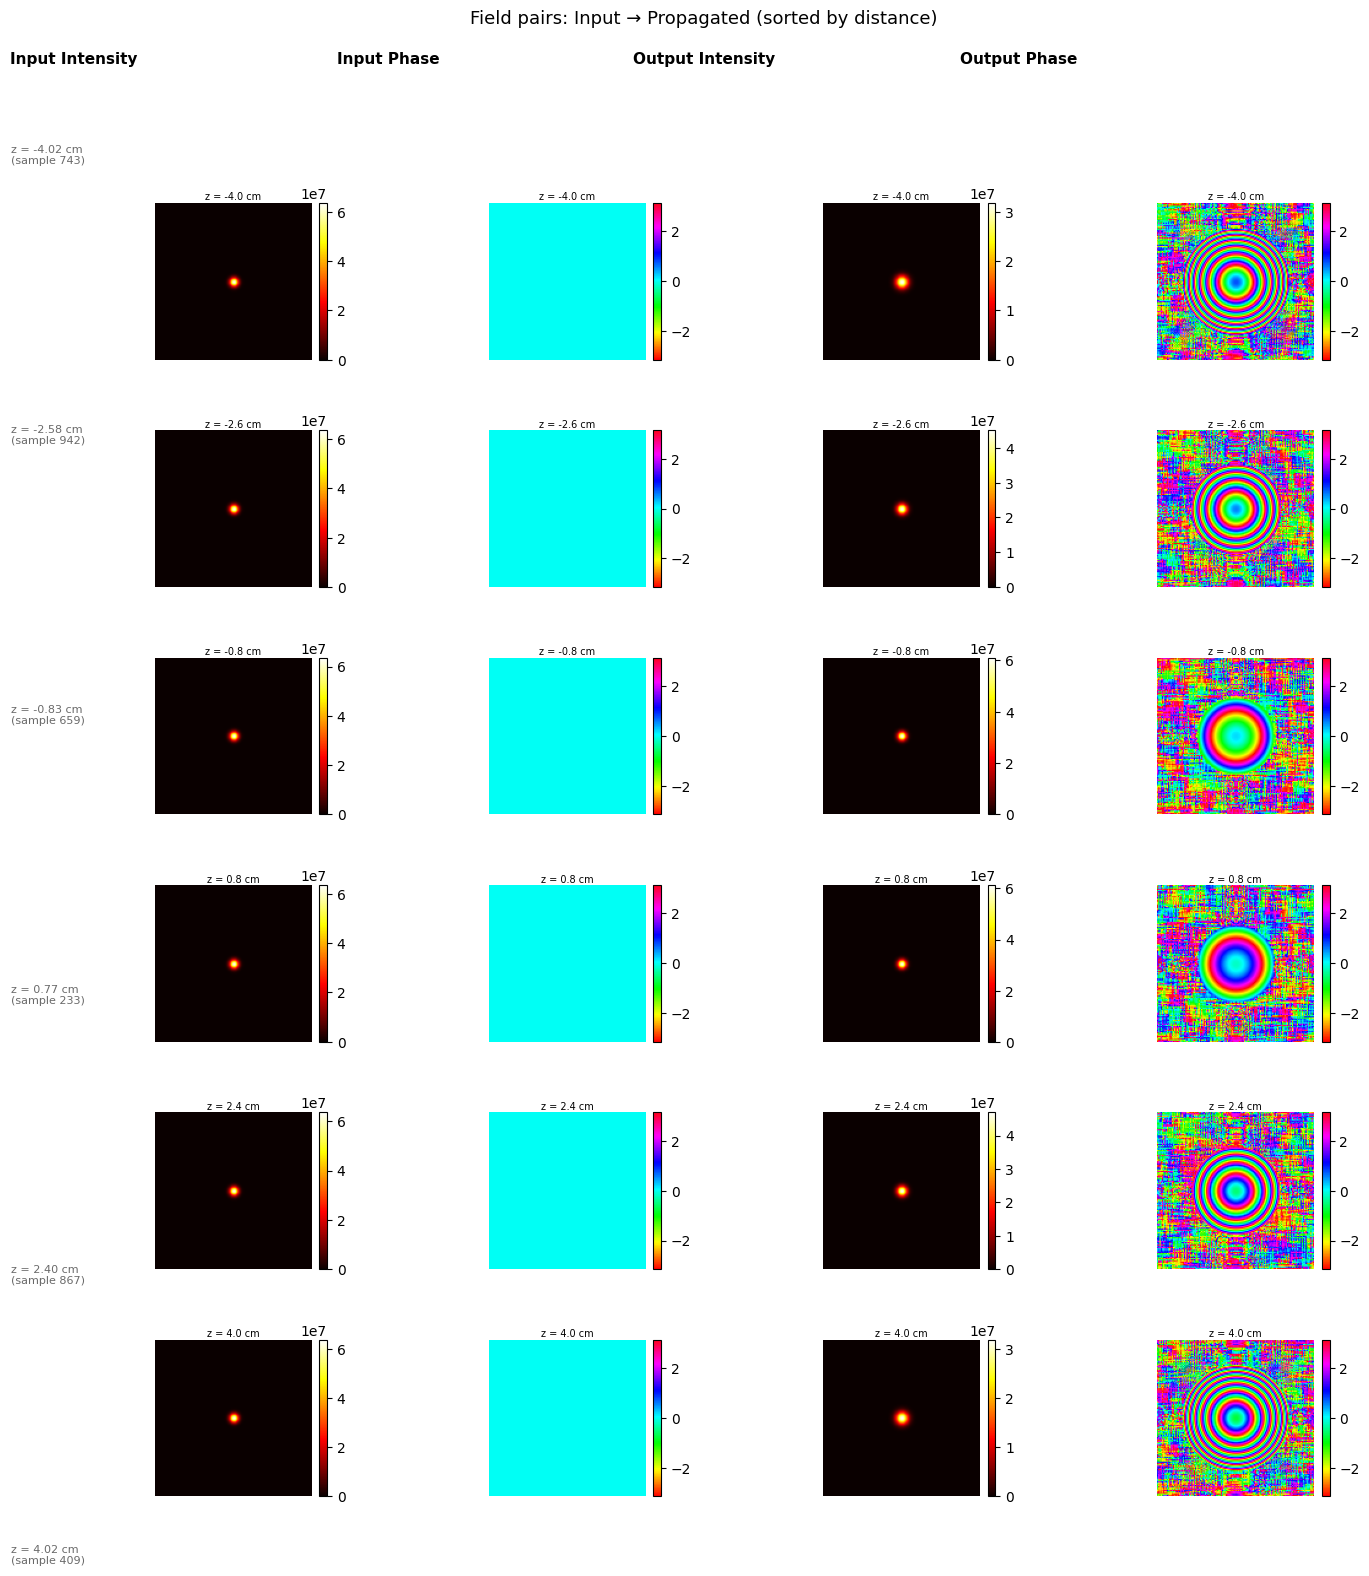

In [7]:
N_GALLERY = 6   # number of samples to show

# Sort selected samples by propagation distance for a nice visual sweep
gallery_idx = np.argsort(z_arr)[np.linspace(0, n_samples - 1, N_GALLERY, dtype=int)]

fig = plt.figure(figsize=(14, N_GALLERY * 2.8))
gs  = gridspec.GridSpec(N_GALLERY, 4,
                        hspace=0.45, wspace=0.3,
                        left=0.05, right=0.95)

col_labels = ["Input Intensity", "Input Phase", "Output Intensity", "Output Phase"]
for col, lbl in enumerate(col_labels):
    fig.text(0.05 + col * 0.225, 0.97, lbl,
             ha="center", va="top", fontsize=11, fontweight="bold")

for row, idx in enumerate(gallery_idx):
    z_cm = z_arr[idx] * 100
    row_label = f"z = {z_cm:.2f} cm\n(sample {idx})"
    fig.text(0.005, 1 - (row + 0.55) / N_GALLERY, row_label,
             va="center", ha="left", fontsize=8, color="dimgray")

    for col, (field, cmap, vmin, vmax) in enumerate([
        (np.abs(E_in[idx])**2,   "hot",  None, None),
        (np.angle(E_in[idx]),    "hsv",  -np.pi, np.pi),
        (np.abs(E_out[idx])**2,  "hot",  None, None),
        (np.angle(E_out[idx]),   "hsv",  -np.pi, np.pi),
    ]):
        ax = fig.add_subplot(gs[row, col])
        im = ax.imshow(field, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.axis("off")
        ax.set_title(f"z = {z_cm:.1f} cm", fontsize=7, pad=2)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03)

plt.suptitle("Field pairs: Input → Propagated (sorted by distance)", fontsize=13, y=0.995)
plt.show()